In [101]:
# ipca_pipeline.py (or paste into a notebook cell)

from __future__ import annotations
import os
import contextlib
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict, Any

import numpy as np
import pandas as pd
from ipca import InstrumentedPCA

def run_pipeline(
    start_yyyymm: str = "199001",
    end_yyyymm: str = "202412",
    max_nan_frac: float = 0.6,
    cutoff: str = "2015-12-31",
    n_factors: int = 3,
) -> Dict[str, Any]:
    df_raw = download_openap_data(start_yyyymm, end_yyyymm)
    df_keep, dropped = remove_mostly_nan_columns(df_raw, max_nan_frac=max_nan_frac)
    df_filled = fill_remaining_missing(df_keep)

    panel = build_ipca_panel(df_filled, ret_col="excess_ret", shift_target=True)
    train_df, test_df = split_train_test_by_date(panel.df, cutoff=cutoff)

    X_train = train_df[panel.char_cols].to_numpy(np.float64)
    y_train = train_df["y_ipca"].to_numpy(np.float64)
    idx_train = train_df[["i_idx", "t_idx"]].to_numpy(np.int64)

    X_test = test_df[panel.char_cols].to_numpy(np.float64)
    y_test = test_df["y_ipca"].to_numpy(np.float64)
    idx_test = test_df[["i_idx", "t_idx"]].to_numpy(np.int64)

    mod = fit_ipca(X_train, y_train, idx_train, n_factors=n_factors, silent=True)
    r2_train = score_ipca(mod, X_train, y_train, idx_train, mean_factor=False)
    r2_test = score_ipca(mod, X_test, y_test, idx_test, mean_factor=True)  # unseen dates

    return {
        "model": mod,
        "dropped_cols": dropped,
        "char_cols": panel.char_cols,
        "r2_train": r2_train,
        "r2_test_mean_factor": r2_test,
        "train_shape": X_train.shape,
        "test_shape": X_test.shape,
    }


In [109]:
%cd ..
import importlib
import src.ipca_workflow as IPCAWorkflow

importlib.reload(IPCAWorkflow)

/Users/apple/Desktop


<module 'src.ipca_workflow' from '/Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master/src/ipca_workflow.py'>

In [110]:
new_mod = IPCAWorkflow.IPCAWorkflow()

In [ ]:
out_path = "/Users/apple/Desktop/Academics/char_data.parquet"
char_data = pd.read_parquet(out_path, engine="pyarrow")

In [11]:
returns_data = new_mod.download_sp500_returns_wrds(start_date="1990-01-01", end_date="2026-01-31")

WRDS recommends setting up a .pgpass file.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [62]:
char_data, dropped_cols = new_mod.remove_mostly_nan_columns(char_data, max_nan_frac=0.5)
print(f"Dropped columns: {dropped_cols}")

Dropped columns: ['AOP', 'AbnormalAccruals', 'AccrualsBM', 'Activism1', 'Activism2', 'AdExp', 'AgeIPO', 'AnalystRevision', 'AnalystValue', 'BetaTailRisk', 'BrandInvest', 'CBOperProf', 'CPVolSpread', 'Cash', 'ChAssetTurnover', 'ChForecastAccrual', 'ChInvIA', 'ChNAnalyst', 'ChangeInRecommendation', 'CitationsRD', 'CompEquIss', 'CompositeDebtIssuance', 'ConsRecomm', 'CustomerMomentum', 'DelBreadth', 'DelDRC', 'DivSeason', 'DivYieldST', 'DownRecomm', 'EP', 'EarnSupBig', 'EarningsConsistency', 'EarningsForecastDisparity', 'EarningsStreak', 'EarningsSurprise', 'EntMult', 'ExclExp', 'FEPS', 'FR', 'FirmAgeMom', 'ForecastDispersion', 'Frontier', 'Governance', 'GrAdExp', 'GrSaleToGrInv', 'GrSaleToGrOverhead', 'HerfAsset', 'HerfBE', 'IO_ShortInterest', 'IndRetBig', 'IntanBM', 'IntanCFP', 'IntanEP', 'IntanSP', 'InvGrowth', 'Investment', 'MS', 'MeanRankRevGrowth', 'Mom6mJunk', 'MomOffSeason06YrPlus', 'MomOffSeason11YrPlus', 'MomOffSeason16YrPlus', 'MomRev', 'MomSeason06YrPlus', 'MomSeason11YrPlus',

In [63]:
char_data, kept_chars, dropped_chars = new_mod.drop_low_std_and_high_corr(
    char_data,
    min_std=1e-5,   # tune as needed
    max_corr=0.75,  # tune as needed
)

/usr/local/lib/python3.11/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [65]:
char_data = new_mod.fill_remaining_missing(char_data)

/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local

In [66]:
char_data_copy = char_data.copy()
char_data.head()

,permno,yyyymm,AM,AnnouncementReturn,AssetGrowth,BMdec,Beta,BetaFP,BetaLiquidityPS,BidAskSpread,...,ShareRepurchase,Spinoff,Tax,VolSD,VolumeTrend,betaVIX,hire,Price,Size,STreversal
0,10000,1986-01-01,1.354349,-0.005048,-0.079363,0.812997,0.939402,0.950803,-0.003676,0.010201,...,0.0,0.0,0.605906,-0.132456,-0.007507,-0.005223,-0.003373,-1.475906,-2.778819,-0.000000
1,10000,1986-02-01,1.288478,-0.006319,-0.078568,0.810572,0.943105,0.946533,-0.002954,0.009883,...,0.0,0.0,0.607135,-0.135303,-0.008091,-0.003476,-0.002513,-1.178655,-2.481568,0.257143
2,10000,1986-03-01,1.241767,-0.005388,-0.077011,0.810708,0.940686,0.945886,-0.003437,0.009717,...,0.0,0.0,0.629491,-0.139121,-0.009545,-0.002722,-0.001701,-1.490091,-2.793004,-0.365385
3,10000,1986-04-01,1.235495,-0.004667,-0.076508,0.810708,0.941277,0.885681,0.001821,0.009709,...,0.0,0.0,0.628357,-0.142124,-0.010400,0.000880,-0.000655,-1.386294,-2.719452,0.098592
4,10000,1986-05-01,1.190630,-0.001813,-0.076775,0.805317,0.940010,0.875988,-0.000560,0.009856,...,0.0,0.0,0.628310,-0.140521,-0.010711,0.008871,-0.001751,-1.134423,-2.467581,0.222656


In [67]:
returns_data = returns_data.rename(columns={"excess_ret": "ret_adj"})
char_data = new_mod.merge_openap_with_crsp_returns(char_data, returns_data)

In [68]:
char_data.head()

,permno,yyyymm,AM,AnnouncementReturn,AssetGrowth,BMdec,Beta,BetaFP,BetaLiquidityPS,BidAskSpread,...,Spinoff,Tax,VolSD,VolumeTrend,betaVIX,hire,Price,Size,STreversal,excess_ret
0,10057,1990-01-01,1.999589,0.007559,0.239249,1.034177,1.051798,1.169400,-0.362514,0.009218,...,0.0,1.00000,-0.198142,0.007066,-0.003199,-0.039773,-2.327278,-4.166398,0.048276,-0.048276
1,10057,1990-02-01,2.024275,0.007559,0.239249,1.034177,1.064015,1.175841,-0.364891,0.008374,...,0.0,1.00000,-0.196566,0.007637,-0.007087,-0.039773,-2.315008,-4.154128,0.012195,-0.012195
2,10057,1990-03-01,2.249233,0.007559,-0.056259,1.102799,1.048140,1.143656,-0.380739,0.011821,...,0.0,0.87482,-0.196829,0.008500,0.003537,-0.027473,-2.264364,-4.103484,0.049383,-0.049383
3,10057,1990-04-01,2.372478,0.000431,-0.056259,1.102799,1.044639,1.178724,-0.384304,0.007117,...,0.0,0.87482,-0.174378,0.009746,-0.010046,-0.027473,-2.211018,-4.050138,0.041558,-0.041558
4,10057,1990-05-01,2.405429,0.000431,-0.056259,1.102799,1.033924,1.203003,-0.372249,0.010140,...,0.0,0.87482,-0.176361,0.011445,-0.000726,-0.027473,-2.197225,-4.036345,0.013699,-0.013699


In [69]:
char_data["y_ipca"] = char_data["excess_ret"].shift(-1)  # next period's return as target

In [ ]:
pred_df, diag_df = new_mod.rolling_ipca_predictions(
    char_data=char_data,          # or char_data directly
    forecast_start="2020-01-01",
    target_col="y_ipca",            # auto-built from excess_ret if missing
    n_factors=5,
    train_window_months=60,        # rolling 10y window; set None for expanding
    min_train_obs=500,
    normalize=True,
    mean_factor=True,
    silent=True,
    max_iter=15,
    iter_tol=1e-3,
    warm_start=True
)
pred_df.head()

Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_start=False
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_start=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_start=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_start=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_start=True


In [16]:
import os, pickle, time
import importlib
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
import src.ipca_workflow as ipw

importlib.reload(ipw)

factor_grid = range(3,9)  # choose your factor models
max_workers = min(len(factor_grid), max(1, (os.cpu_count() or 2) // 2))
CKPT = "ipca_factor_results.pkl"

# load checkpoint
if os.path.exists(CKPT):
    with open(CKPT, "rb") as f:
        results = pickle.load(f)

def run_one_factor(k: int):
    wf = ipw.IPCAWorkflow()
    to = time.time()
    pred = wf.rolling_ipca_predictions(
        char_data=char_data,          # or filtered char_data
        forecast_start="2020-01-01",
        n_factors=k,
        train_window_months=120,      # or None
        normalize=True,
        silent=True,
        iter_tol=1e-3,
        max_iter=100,
    )
    pred["n_factors"] = k
    return k, pred, time.time() -to

results = {}
with ThreadPoolExecutor(max_workers=3) as ex:
    futures = {ex.submit(run_one_factor, k): k for k in factor_grid}
    for fut in as_completed(futures):
        k, pred_df, secs = fut.result()
        results[k] = pred_df
        with open(CKPT, "wb") as f:
            pickle.dump(results, f)
            print(f"done k={k} in {secs/60:.1f} min; checkpoint saved")
# combined predictions for all factor models
all_preds = pd.concat(results.values(), ignore_index=True).sort_values(["n_factors", "yyyymm", "permno"])
all_preds.head()


StepStep 16 - Aggregate Update: 0.00273321605036312
 21 - Aggregate Update: 0.00791466019805015
Step 3 - Aggregate Update: 1.2331000126711933
Step 88 - Aggregate Update: 0.01763596359076658


: 

In [80]:
pred_df

,permno,yyyymm,y_true,y_pred,train_end,n_train,n_test
0,10104,2020-01-01,-0.057007,0.000240,2019-12-01,180230,505
1,10107,2020-01-01,-0.045292,0.000589,2019-12-01,180230,505
2,10138,2020-01-01,-0.116229,0.000427,2019-12-01,180230,505
3,10145,2020-01-01,-0.058596,0.000418,2019-12-01,180230,505
4,10516,2020-01-01,-0.150804,0.000209,2019-12-01,180230,505
...,...,...,...,...,...,...,...
30232,93096,2024-12-01,-0.109353,-0.000220,2024-11-01,209951,503
30233,93132,2024-12-01,0.156696,0.000267,2024-11-01,209951,503
30234,93246,2024-12-01,NaN,0.000198,2024-11-01,209951,503
30235,93429,2024-12-01,0.243252,0.000195,2024-11-01,209951,503


/var/folders/nf/zfnfl40j2hb_zjsqj1rbjq140000gn/T/ipykernel_63260/504543675.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_r2 = pred_df.groupby("yyyymm").apply(oos_r2)


<Axes: title={'center': 'Monthly OOS R²'}, xlabel='yyyymm'>

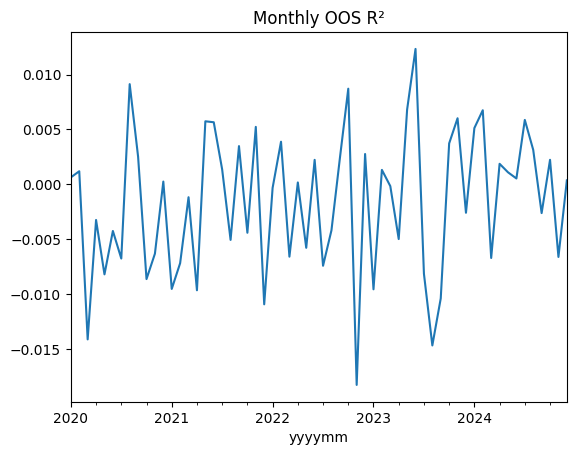

In [94]:
def oos_r2(g):
    ss_res = ((g["y_true"] - g["y_pred"]) ** 2).sum()
    ss_tot = (g["y_true"] ** 2).sum()
    return 1 - ss_res / ss_tot

monthly_r2 = pred_df.groupby("yyyymm").apply(oos_r2)
monthly_r2.plot(title="Monthly OOS R²")

In [95]:
# Overall OOS R²
ss_res = ((pred_df["y_true"] - pred_df["y_pred"]) ** 2).sum()
ss_tot = (pred_df["y_true"] ** 2).sum()  # demeaned vs zero (standard in asset pricing)
r2_oos = 1 - ss_res / ss_tot
print(f"OOS R²: {r2_oos:.4f}")

OOS R²: -0.0023


In [104]:
%cd ..
import src.portfolio_utils as pu

from src.portfolio_utils import (
    build_long_only_portfolio,
    compute_portfolio_returns,
    portfolio_performance,
    plot_cumulative,
)

/Users/apple/Desktop/Academics/Research_work


In [103]:
%cd /Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master

import sys, importlib
if "src.portfolio_utils" in sys.modules:
    del sys.modules["src.portfolio_utils"]

/Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master


Annualized Return : 11.32%
Annualized Vol    : 19.29%
Sharpe Ratio      : 0.59
Max Drawdown      : -28.13%
Hit Rate          : 63.33%


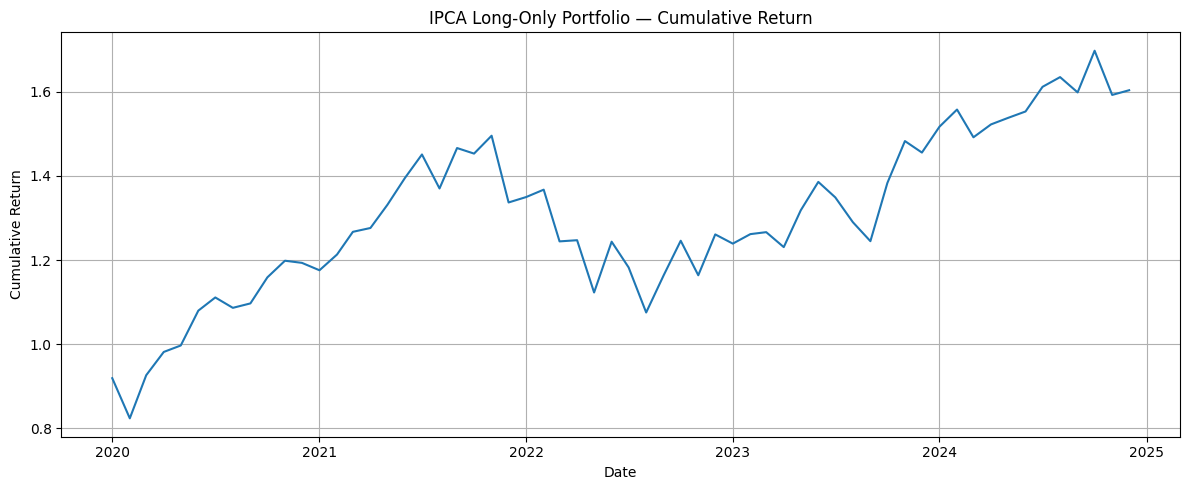

In [105]:
port     = build_long_only_portfolio(pred_df, top_n=100)  # top 100 stocks
monthly  = compute_portfolio_returns(port)
stats    = portfolio_performance(monthly)
plot_cumulative(monthly)